# 2. Filtering

Thinning, cropping, outlier removal and local geometry from `sylva.filters`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import filters

cloud = synthetic.forest()

## Subsampling

In [2]:
thin = {
    "voxel 5 cm": filters.voxel_downsample(cloud, 0.05),
    "voxel 5 cm (centroid)": filters.voxel_downsample(cloud, 0.05, method="centroid"),
    "random 20 %": filters.random_subsample(cloud, fraction=0.2),
    "min distance 5 cm": filters.min_distance_subsample(cloud, 0.05),
}
for k, v in thin.items():
    print(f"{k:24s} {len(v):>8,} of {len(cloud):,}")

voxel 5 cm                102,696 of 314,795
voxel 5 cm (centroid)     102,696 of 314,795
random 20 %                62,959 of 314,795
min distance 5 cm          67,105 of 314,795


## Crops

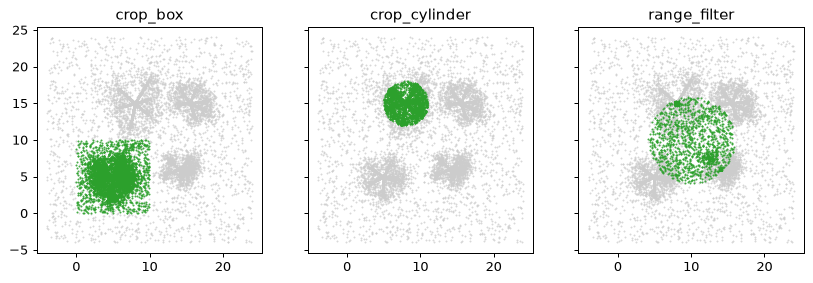

In [3]:
box = filters.crop_box(cloud, (0, 0, -1), (10, 10, 30))
cyl = filters.crop_cylinder(cloud, (8.0, 15.0), radius=3.0)
near = filters.range_filter(cloud, origin=(10, 10, 1.5), max_range=6.0)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
for a, (name, c) in zip(ax, {"crop_box": box, "crop_cylinder": cyl, "range_filter": near}.items()):
    a.scatter(cloud.x[::20], cloud.y[::20], s=0.2, c="0.8")
    a.scatter(c.x[::5], c.y[::5], s=0.3, c="C2")
    a.set(title=name, aspect="equal")

## Outliers

Add 500 stray points and remove them again. Statistical removal compares each point's mean neighbour distance with the cloud-wide distribution; radius removal needs a minimum number of neighbours.

In [4]:
rng = np.random.default_rng(1)
lo, hi = cloud.bounds
noise = rng.uniform(lo, hi + [0, 0, 5], (500, 3))
noisy = sylva.PointCloud(np.vstack([cloud.xyz, noise]))
is_noise = np.arange(len(noisy)) >= len(cloud)

sor = filters.statistical_outlier_removal(noisy, k=8, std_ratio=2.0, return_mask=True)
ror = filters.radius_outlier_removal(noisy, radius=0.25, min_neighbors=4, return_mask=True)
for name, keep in (("statistical", sor), ("radius", ror)):
    print(f"{name:12s} removed {np.sum(~keep & is_noise)} of 500 stray points and {np.sum(~keep & ~is_noise)} real ones")

statistical  removed 479 of 500 stray points and 44 real ones
radius       removed 481 of 500 stray points and 503 real ones


## Local geometry

PCA over the `k` nearest neighbours gives normals and the planarity / linearity used by the wood filter: stems and branches are planar or linear at this scale, foliage is neither.

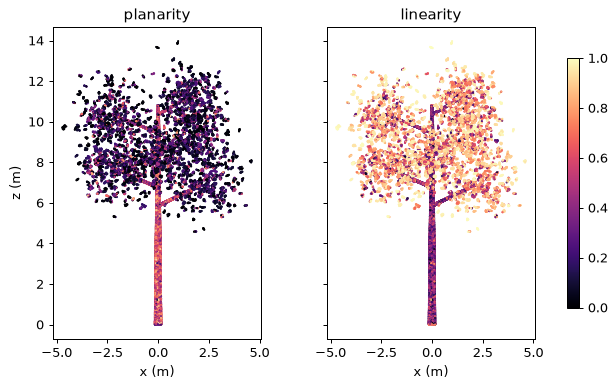

In [5]:
t = synthetic.tree(seed=3)
planarity, linearity = filters.planarity_linearity(t, k=20)
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5), sharey=True)
for a, v, name in ((ax[0], planarity, "planarity"), (ax[1], linearity, "linearity")):
    s = a.scatter(t.x, t.z, c=v, s=0.4, cmap="magma", vmin=0, vmax=1)
    a.set(title=name, xlabel="x (m)", aspect="equal")
ax[0].set_ylabel("z (m)")
fig.colorbar(s, ax=ax, shrink=0.8);

## Clustering

`euclidean_clusters` labels connected components (points closer than `radius`). Above the ground the four trees separate.

clusters: 10  unassigned points: 9030


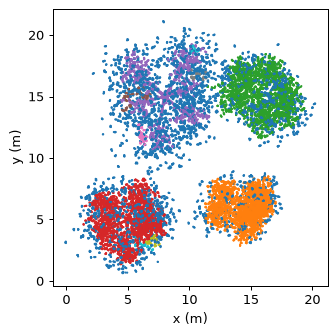

In [6]:
above = cloud[cloud.z - synthetic.terrain_height(cloud.x, cloud.y) > 0.5]
above = filters.voxel_downsample(above, 0.1)
labels = filters.euclidean_clusters(above.xyz, radius=0.35, min_points=50)
print("clusters:", labels.max() + 1, " unassigned points:", np.sum(labels < 0))
plt.scatter(above.x, above.y, c=labels, s=0.5, cmap="tab10")
plt.gca().set(aspect="equal", xlabel="x (m)", ylabel="y (m)");